In [1]:
# ==========================================
# Jupyter Notebook: Extracción de Malla Vial
# Comuna: San Miguel, Santiago, Chile
# Autor: Gerardo Ureta, PhD(c) en Industria Inteligente, PUCV
# ==========================================

# 1. Instalación de librerías (ejecutar una vez)
# !pip install osmnx geopandas shapely fiona pyproj

In [2]:
# 2. Importación de librerías
import osmnx as ox
import geopandas as gpd

# Configuración opcional
ox.settings.log_console = True
ox.settings.use_cache = True

In [3]:
# 3. Definir área de estudio
place_name = "San Miguel, Santiago, Chile"

In [4]:
# 4. Descargar red vial desde OpenStreetMap
# network_type="drive" -> solo calles transitables por vehículos
G = ox.graph_from_place(place_name, network_type='drive')

In [5]:
# 5. Convertir grafo a GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)

In [6]:
# 6. Revisar estructura
print(edges.head())
print(edges.crs)

                              osmid   highway lanes maxspeed  \
u         v          key                                       
14760603  243485726  0    355376018   primary     2       50   
          335617919  0    649329116  tertiary     3       50   
14760609  3010902319 0     22698947   primary     2      NaN   
          267807538  0     38942685  tertiary     2      NaN   
149825401 5148748242 0    860489355   primary     3      NaN   

                                                    name  oneway  reversed  \
u         v          key                                                     
14760603  243485726  0                          Euclides    True     False   
          335617919  0             San Ignacio de Loyola    True     False   
14760609  3010902319 0                              Orán    True     False   
          267807538  0                          Euclides    True     False   
149825401 5148748242 0    Avenida Carlos Silva Vildósola    True     False   

    

In [7]:
# 7. Reproyectar a sistema de coordenadas adecuado para Chile
# WGS84 -> EPSG:4326 (por defecto)
# Proyección recomendada: EPSG:32719 (UTM Zona 19 Sur)
edges_proj = edges.to_crs(epsg=32719)

In [8]:
# 8. Guardar como Shapefile
output_path = "malla_vial_san_miguel.shp"
edges_proj.to_file(output_path)

print(f"Archivo guardado en: {output_path}")

Archivo guardado en: malla_vial_san_miguel.shp


<Axes: >

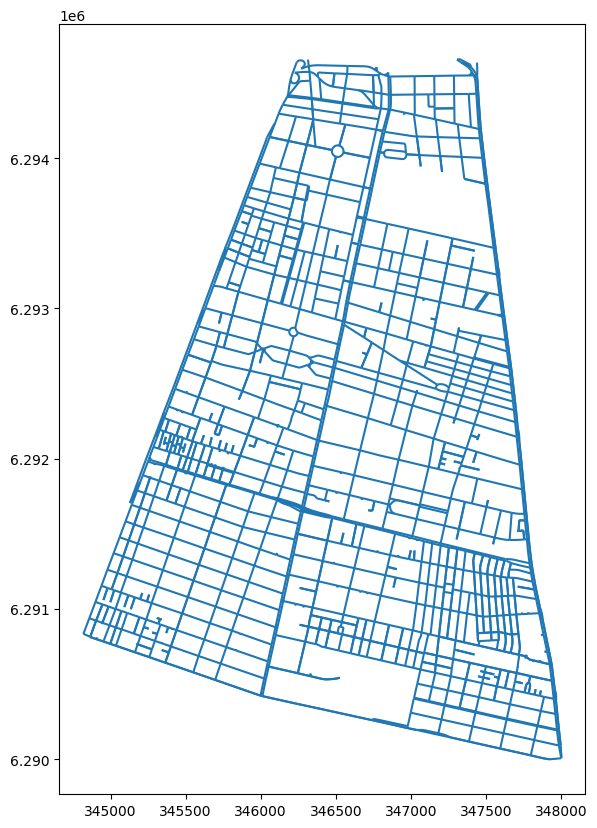

In [9]:
# 9. (Opcional) Visualización rápida
edges_proj.plot(figsize=(10,10))


In [10]:
# ==========================================
# Notas técnicas:
# - Fuente de datos: OpenStreetMap
# - Precisión depende del mapeo colaborativo
# - Puede filtrarse por tipo de vía (highway)
# ==========================================

In [11]:
# 10. Filtrar tipos de calles
# Ejemplo: excluir caminos menores
if 'highway' in edges.columns:
    edges_filtrado = edges[edges['highway'].isin(['primary','secondary','tertiary','residential'])]
    edges_filtrado = edges_filtrado.to_crs(epsg=32719)
    edges_filtrado.to_file("malla_vial_filtrada.shp")
    print("Archivo filtrado guardado")

Archivo filtrado guardado


In [12]:
# 11. Exportar nodos también
nodes_proj = nodes.to_crs(epsg=32719)
nodes_proj.to_file("nodos_viales_san_miguel.shp")

print("Proceso completado correctamente")

Proceso completado correctamente


C:\Users\anton\AppData\Local\Temp\ipykernel_17316\1804516133.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes_proj.to_file("nodos_viales_san_miguel.shp")
C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


Intersecciones críticas (nodos)

In [13]:
import osmnx as ox
G = ox.graph_from_place("San Miguel, Santiago, Chile", network_type="drive")
nodes, edges = ox.graph_to_gdfs(G)

# Nodos con alta conectividad
nodos_criticos = nodes[nodes['street_count'] >= 4]